# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [2]:
import pandas as pd
df = pd.read_csv('data/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [4]:
print(df['loan_status'].value_counts())

print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
# Удаление выбросов (аномальные значения возраста > 100 и стажа > 60), искажающих статистику
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

# Заполняем пропуски (NaN)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Проверим результат
print("Осталось строк после удаления выбросов:", len(df))
df.info()

Осталось строк после удаления выбросов: 31679
<class 'pandas.DataFrame'>
Index: 31679 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31679 non-null  int64  
 1   person_income               31679 non-null  int64  
 2   person_home_ownership       31679 non-null  str    
 3   person_emp_length           31679 non-null  float64
 4   loan_intent                 31679 non-null  str    
 5   loan_grade                  31679 non-null  str    
 6   loan_amnt                   31679 non-null  int64  
 7   loan_int_rate               31679 non-null  float64
 8   loan_status                 31679 non-null  int64  
 9   loan_percent_income         31679 non-null  float64
 10  cb_person_default_on_file   31679 non-null  str    
 11  cb_person_cred_hist_length  31679 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.1 MB


In [8]:
# Превратить текст в (0 и 1)
df = pd.get_dummies(df, drop_first=True)

# Посмотреть, что изменилось
df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False


In [9]:
from sklearn.model_selection import train_test_split

# Отделяем признаки (X) от ответов (y)
# Формирование матрицы признаков (X) и вектора целевой переменной (y)
X = df.drop('loan_status', axis=1)

# y - это только колонка с ответами (1 - дефолт, 0 - вернул)
y = df['loan_status']

# Разбиваем данные на Train и Test
# random_state=42 нужен, чтобы разделение было одинаковым при каждом запуске
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Проверяем, сколько строк пошло куда
print("Строк для обучения:", len(X_train))
print("Строк для экзамена:", len(X_test))

Строк для обучения: 25343
Строк для экзамена: 6336


In [11]:
# Импортируем алгоритм дерева решений и проверяем оценку
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


# max_depth=5 - это ограничение глубины дерева
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Показываем модели обучающие данные (X_train) и правильные ответы к ним (y_train)
model.fit(X_train, y_train)
print("Модель успешно обучена!\n")

y_pred = model.predict(X_test)

print("Общая точность модели (Accuracy):", accuracy_score(y_test, y_pred))
print("\nПодробный отчет:\n", classification_report(y_test, y_pred))

Модель успешно обучена!

Общая точность модели (Accuracy): 0.8999368686868687

Подробный отчет:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94      4963
           1       0.95      0.57      0.71      1373

    accuracy                           0.90      6336
   macro avg       0.92      0.78      0.82      6336
weighted avg       0.91      0.90      0.89      6336



In [12]:
# Создаем новую модель, но теперь добавляем балансировку весов (class_weight='balanced')
model_balanced = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

# Обучаем ее
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

# Смотрим новые оценки
print("Новый подробный отчет:\n", classification_report(y_test, y_pred_balanced))

Новый подробный отчет:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93      4963
           1       0.74      0.73      0.73      1373

    accuracy                           0.88      6336
   macro avg       0.83      0.83      0.83      6336
weighted avg       0.88      0.88      0.88      6336



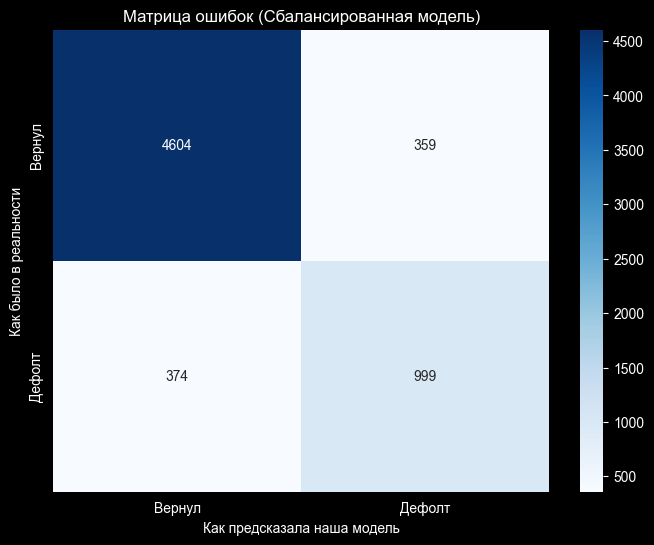

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Считаем матрицу ошибок
cm = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Вернул', 'Дефолт'],
            yticklabels=['Вернул', 'Дефолт'])

plt.title('Матрица ошибок (Сбалансированная модель)')
plt.xlabel('Как предсказала наша модель')
plt.ylabel('Как было в реальности')
plt.show()